# V-Beam Thermal Sensor - Analytical Formula Analysis

Compares beam-mechanics analytical predictions
against FEA results in the dataset.


## 1. Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Data

In [17]:
EXCEL_PATH = "../Data/Datasets/Dataset_complet_5.11.2025 - Copy.xlsx"

df = pd.read_excel(EXCEL_PATH)
print(f"Dataset shape: {df.shape}")

INPUT_COLS  = ["Beta Angle", "Beam Length", "Beam Width",
               "Delta Temp", "Young's Modulus - E", "CTE - alpha"]
OUTPUT_COLS = ["Sensor Displacement", "Max Mechanical Stress", "Vol"]

df_clean = df[INPUT_COLS + OUTPUT_COLS].dropna()
print(f"Clean rows: {len(df_clean)}")
print()
print(df_clean.describe())

Dataset shape: (3000, 30)
Clean rows: 3000

        Beta Angle  Beam Length   Beam Width   Delta Temp  \
count  3000.000000  3000.000000  3000.000000  3000.000000   
mean     24.993200    27.510467     1.499800    45.292500   
std       8.670222     4.281793     0.295583    14.446169   
min      10.000000    20.000000     1.000000    20.000000   
25%      17.600000    23.800000     1.200000    32.800000   
50%      24.850000    27.600000     1.500000    45.100000   
75%      32.500000    31.200000     1.800000    57.900000   
max      40.000000    35.000000     2.000000    70.000000   

       Young's Modulus - E   CTE - alpha  Sensor Displacement  \
count               3000.0  3.000000e+03          3000.000000   
mean               71000.0  2.300000e-05             0.090790   
std                    0.0  3.388697e-21             0.042193   
min                71000.0  2.300000e-05             0.024984   
25%                71000.0  2.300000e-05             0.059721   
50%             

## 3. Analytical Beam-Mechanics Formulas

In [18]:
ALPHA_AL = 23e-6
ALPHA_SI = 5.7e-6
T_THICK  = 1.0
N_PAIRS  = 3.0
D_DIST   = 10.0
W_ANCHOR = 3.0
W_SHAFT  = 3.0

def analytical_numpy(beta_deg, l, w, delta_T, E, alpha_Al):
    beta = beta_deg * np.pi / 180.0
    t    = T_THICK
    A    = w * t
    Iz   = t * w**3 / 12.0
    Wz   = t * w**2 / 6.0
    Al2  = A * l**2

    e    = (W_ANCHOR + W_SHAFT + l * np.cos(beta)) * 2 * ALPHA_SI * delta_T
    ThL  = -E * A * alpha_Al * delta_T

    denom = 12*Iz*l*np.cos(beta)**2 + A*l**3*np.sin(beta)**2
    H     = -(12*e*E*A*Iz + 12*ThL*Iz*l*np.cos(beta)) / denom

    M_r  = H * l * np.sin(beta) / 2.0
    Mb   = M_r - H * l * np.sin(beta)
    N    = ThL + H * np.cos(beta)
    sigma_eq = np.sqrt((N/A + Mb/Wz)**2 + 3*(H*np.sin(beta)/A)**2)

    denom_v = 12*Iz*np.cos(beta)**2 + Al2*np.sin(beta)**2
    v = (alpha_Al * delta_T * l * np.sin(beta)
         + (e + alpha_Al*delta_T*l*np.cos(beta))
           * (Al2 - 12*Iz) * np.sin(beta)*np.cos(beta) / denom_v)

    vol = 2*t*(N_PAIRS*l*w + (N_PAIRS*D_DIST + w/np.cos(beta)) * (W_ANCHOR + W_SHAFT))
    return v, sigma_eq, vol

## 4. Compute Analytical Predictions and Compare with FEA

In [19]:
v_an, s_an, vol_an = analytical_numpy(
    df_clean["Beta Angle"].values, df_clean["Beam Length"].values,
    df_clean["Beam Width"].values, df_clean["Delta Temp"].values,
    df_clean["Young's Modulus - E"].values, df_clean["CTE - alpha"].values,
)

# sf = df["Equivalent Stress - SigmaEq"] / df["Max Mechanical Stress"]
# STRESS_FACTOR = float(sf.dropna().mean())
# s_an_corr = s_an / STRESS_FACTOR

v_fea   = df_clean["Sensor Displacement"].values
s_fea   = df_clean["Max Mechanical Stress"].values
vol_fea = df_clean["Vol"].values

def mape(pred, true): return np.mean(np.abs(pred - true) / np.abs(true)) * 100
def rmse(pred, true): return np.sqrt(np.mean((pred - true)**2))

# print(f"Stress correction factor  : {STRESS_FACTOR:.4f}")
print()
print("Analytical baseline vs FEA data:")
print(f"  Displacement  — MAPE: {mape(v_an, v_fea):.2f}%   RMSE: {rmse(v_an, v_fea):.5f} mm")
print(f"  Stress (corr) — MAPE: {mape(s_an, s_fea):.2f}%   RMSE: {rmse(s_an, s_fea):.3f} MPa")
print(f"  Volume        — MAPE: {mape(vol_an, vol_fea):.6f}%   RMSE: {rmse(vol_an, vol_fea):.5f} mm³")


Analytical baseline vs FEA data:
  Displacement  — MAPE: 27.91%   RMSE: 0.04134 mm
  Stress (corr) — MAPE: 21.63%   RMSE: 16.206 MPa
  Volume        — MAPE: 0.000000%   RMSE: 0.00000 mm³


## 5. Parity Plots — Analytical vs FEA

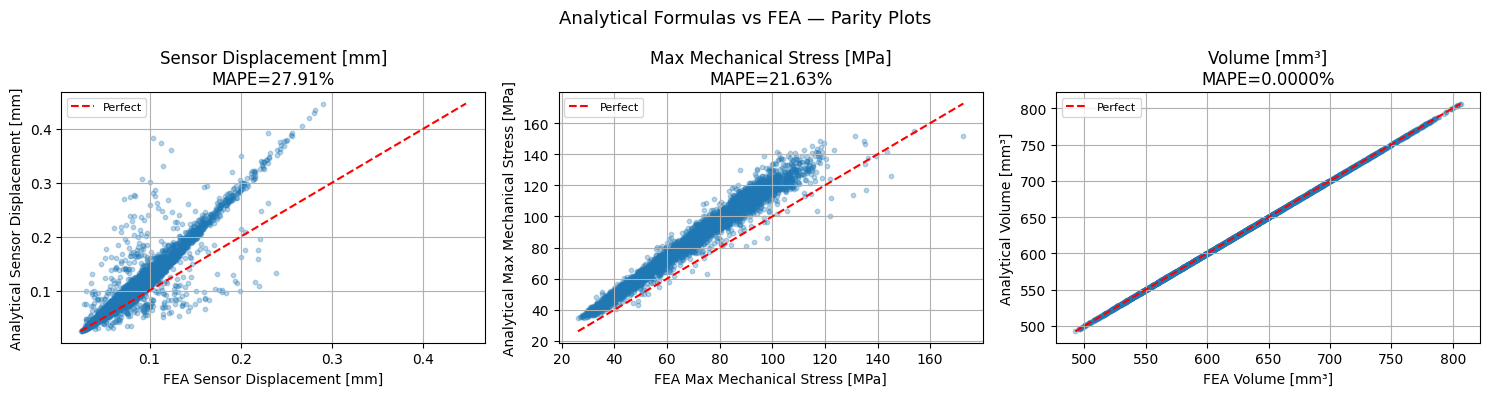

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_data = [
    (v_an,      v_fea,   "Sensor Displacement [mm]",     f"MAPE={mape(v_an, v_fea):.2f}%"),
    (s_an, s_fea,   "Max Mechanical Stress [MPa]",  f"MAPE={mape(s_an, s_fea):.2f}%"),
    (vol_an,    vol_fea, "Volume [mm³]",             f"MAPE={mape(vol_an, vol_fea):.4f}%"),
]

for ax, (pred, true, label, info) in zip(axes, plot_data):
    ax.scatter(true, pred, alpha=0.3, s=10, color="tab:blue")
    lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect")
    ax.set_xlabel(f"FEA {label}"); ax.set_ylabel(f"Analytical {label}")
    ax.set_title(f"{label}\n{info}"); ax.legend(fontsize=8); ax.grid(True)

plt.suptitle("Analytical Formulas vs FEA — Parity Plots", fontsize=13)
plt.tight_layout(); plt.show()

## 6. Error Histograms

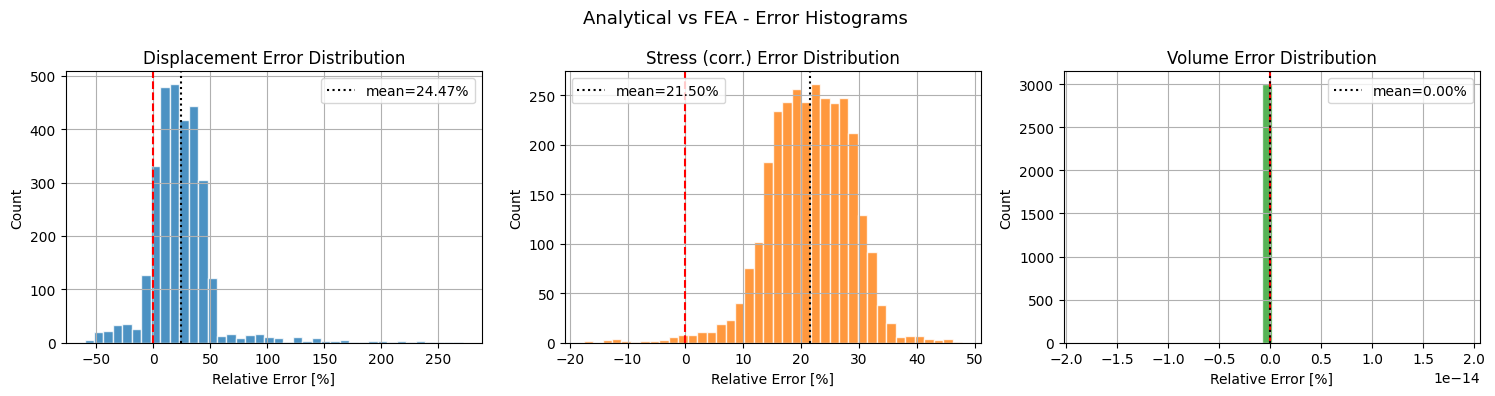

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
err_data = [
    ((v_an - v_fea) / v_fea * 100,           "Displacement",    "tab:blue"),
    ((s_an - s_fea) / s_fea * 100,       "Stress (corr.)", "tab:orange"),
    ((vol_an - vol_fea) / vol_fea * 100,       "Volume",          "tab:green"),
]

for ax, (err, label, color) in zip(axes, err_data):
    ax.hist(err, bins=40, color=color, edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", lw=1.5, linestyle="--")
    ax.axvline(np.mean(err), color="black", lw=1.5, linestyle=":",
               label=f"mean={np.mean(err):.2f}%")
    ax.set_xlabel("Relative Error [%]"); ax.set_ylabel("Count")
    ax.set_title(f"{label} Error Distribution"); ax.legend(); ax.grid(True)

plt.suptitle("Analytical vs FEA - Error Histograms", fontsize=13)
plt.tight_layout(); plt.show()

## 7. Displacement Error vs Geometry Parameters

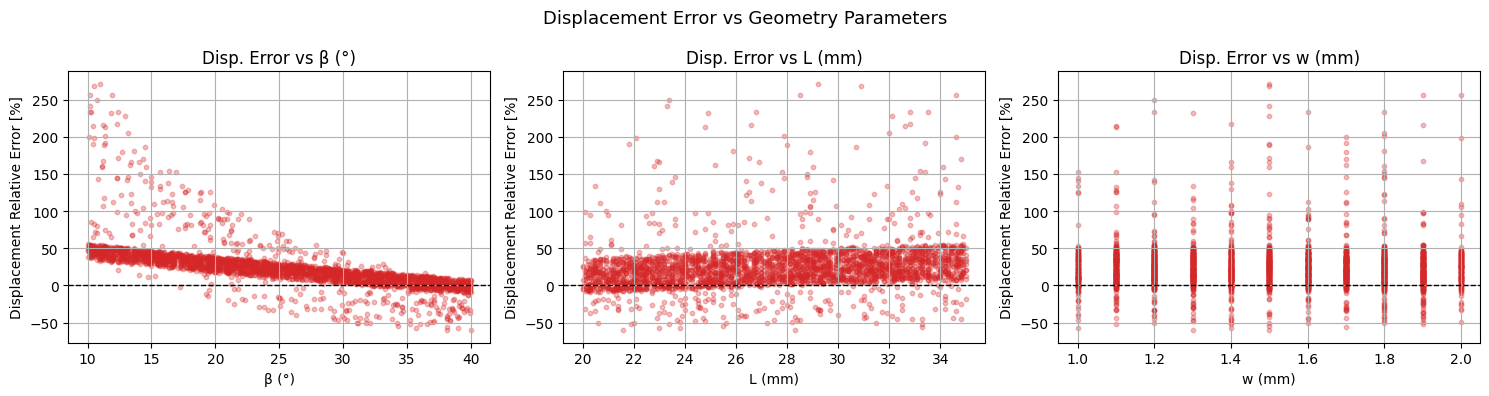

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
disp_err_pct = (v_an - v_fea) / v_fea * 100

params_to_plot = [
    ("Beta Angle",  "β (°)"),
    ("Beam Length", "L (mm)"),
    ("Beam Width",  "w (mm)"),
]

for ax, (col, label) in zip(axes, params_to_plot):
    ax.scatter(df_clean[col].values, disp_err_pct, alpha=0.3, s=10, color="tab:red")
    ax.axhline(0, color="black", lw=1, linestyle="--")
    ax.set_xlabel(label); ax.set_ylabel("Displacement Relative Error [%]")
    ax.set_title(f"Disp. Error vs {label}"); ax.grid(True)

plt.suptitle("Displacement Error vs Geometry Parameters", fontsize=13)
plt.tight_layout(); plt.show()

## 8. Save Analytical Predictions to Excel

Appends `Analytical Displacement`, `Analytical Stress Corr.`, and `Displacement Error [%]`  
as new columns in the dataset file.

In [24]:
from openpyxl import load_workbook

out_path = EXCEL_PATH  

wb = load_workbook(out_path)
ws = wb.active

last_col = max((cell.column for cell in ws[1] if cell.value is not None), default=0)
nc = last_col + 1

ws.cell(row=1, column=nc,     value="Analytical Displacement [mm]")
ws.cell(row=1, column=nc + 1, value="Analytical Stress Corr. [MPa]")
ws.cell(row=1, column=nc + 2, value="Displacement Error [%]")

for i, (v, s, e) in enumerate(zip(v_an, s_an,
                                    (v_an - v_fea) / v_fea * 100), start=2):
    ws.cell(row=i, column=nc,     value=float(v))
    ws.cell(row=i, column=nc + 1, value=float(s))
    ws.cell(row=i, column=nc + 2, value=float(e))

wb.save(out_path)
print(f"Analytical predictions appended to: {out_path}")

Analytical predictions appended to: ../Data/Datasets/Dataset_complet_5.11.2025 - Copy.xlsx
